# Unsupervised Learning: Dimensionality Reduction

In our previous lesson, we learned how to discover hidden groupings in unlabeled data using Clustering. But what happens if the data we are trying to cluster has 500 columns? 

In Machine Learning, adding more features is not always better. Beyond a certain point, adding dimensions causes the **Curse of Dimensionality**—computational costs explode, distances between points become mathematically meaningless, and visualizing the data becomes physically impossible for the human brain.

To solve this, we must use **Dimensionality Reduction**. In this lesson, we will explore the undisputed king of linear compression: **Principal Component Analysis (PCA)**.

PCA is a mathematical technique used to compress a massive Feature Matrix ($X$) into a smaller set of variables while retaining as much of the original information (variance) as possible. It is heavily used in enterprise data pipelines to compress images, speed up training times, and visualize highly complex datasets on a 2D screen.

Let's set up our Python environment to crack open the Linear Algebra that makes this possible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Linear Algebra & Compression Environment Ready.")

✅ Linear Algebra & Compression Environment Ready.


# 1. The Mathematics of Compression

Imagine a dataset with two highly correlated features: `Square Footage` and `House Price`. If you know the square footage, you can largely guess the price. Storing both columns is highly redundant. PCA realizes this redundancy and squashes the two columns into a single, new column (a "Principal Component") that captures the essence of both.

How does it find this mathematically? It relies on the **Covariance Matrix** and **Eigen-decomposition**.

### Step 1: Standardization (Centering the Data)
Before PCA can work, every feature must be scaled to have a mean ($\mu$) of 0 and a variance of 1. If we do not scale the data, PCA will mistakenly think that a feature measured in millions (like Salary) is mathematically more important than a feature measured in decimals (like Interest Rate).

### Step 2: The Covariance Matrix ($\Sigma$)
Next, the algorithm calculates how every single feature in the dataset relates to every other feature. This creates an $n \times n$ matrix (where $n$ is the number of features).
$$\Sigma = \frac{1}{m-1} X^T X$$
*(Where $X$ is the mean-centered feature matrix, and $m$ is the number of samples).*

### Step 3: Eigenvectors and Eigenvalues
Using advanced linear algebra, PCA decomposes the Covariance Matrix into its core directional components. 
$$\Sigma v = \lambda v$$
* **Eigenvectors ($v$)**: The directions (axes) in the data where the variance is the highest. These become our new "Principal Components."
* **Eigenvalues ($\lambda$)**: A number representing exactly *how much* variance exists in that specific direction. 

**The core rule of PCA:** The first Principal Component (PC1) is the eigenvector with the largest eigenvalue. It explains the maximum possible spread of the data. PC2 is the eigenvector with the second-largest eigenvalue, with the strict mathematical constraint that it must be perfectly perpendicular (orthogonal) to PC1.

# 2. Visualizing Eigenvectors in 2D

Let's simulate a highly correlated 2D dataset. We will train PCA to find the Eigenvectors and physically draw them as arrows over our data.

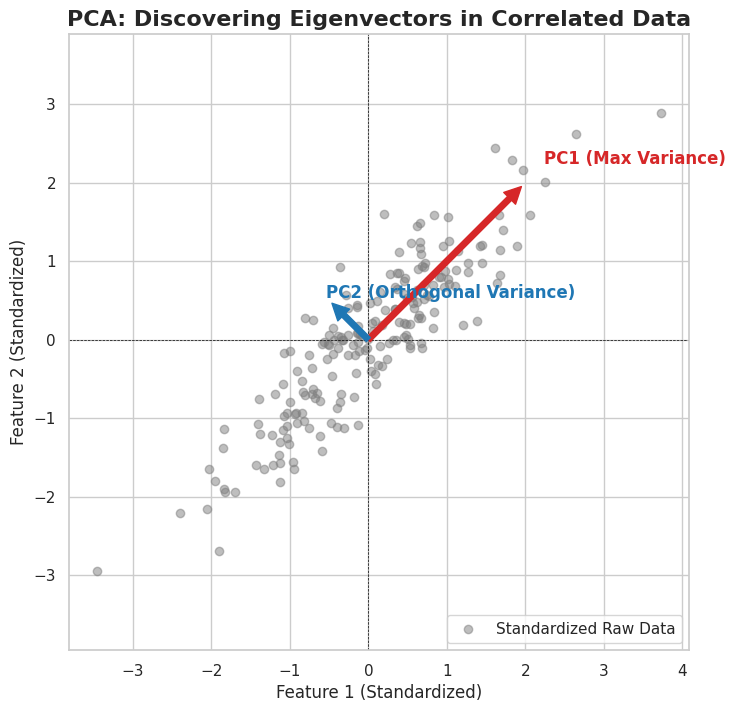

In [2]:
# 1. Simulate Highly Correlated 2D Data
np.random.seed(42)
# Create a stretched oval shape
X_raw = np.dot(np.random.rand(2, 2), np.random.randn(2, 200)).T

# STEP 1: Standardize the Data (Crucial for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# STEP 2 & 3: Fit PCA to calculate Covariance and Eigen-decomposition
pca = PCA(n_components=2)
pca.fit(X_scaled)

# Extract the Math
eigenvectors = pca.components_
eigenvalues = pca.explained_variance_

# 4. Matplotlib Visualization
plt.figure(figsize=(8, 8))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.5, color='#7f7f7f', label='Standardized Raw Data')

# Plot the Eigenvectors (Principal Components) as Arrows
colors = ['#d62728', '#1f77b4']
labels = ['PC1 (Max Variance)', 'PC2 (Orthogonal Variance)']

for i, (vector, value) in enumerate(zip(eigenvectors, eigenvalues)):
    # The length of the arrow is scaled by the square root of the Eigenvalue (Standard Deviation)
    arrow_length = vector * np.sqrt(value) * 2 
    plt.annotate('', xy=arrow_length, xytext=(0, 0),
                 arrowprops=dict(facecolor=colors[i], edgecolor=colors[i], width=4, headwidth=12))
    
    # Add text labels at the tip of the arrows
    plt.text(arrow_length[0] * 1.15, arrow_length[1] * 1.15, 
             labels[i], color=colors[i], fontsize=12, fontweight='bold')

plt.title("PCA: Discovering Eigenvectors in Correlated Data", fontsize=16, fontweight='bold')
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.axis('equal') # Ensure the scale is visually 1:1 so orthogonal vectors actually look 90 degrees
plt.legend(loc='lower right')
plt.show()

*(Insight: Look at the red arrow (PC1). It cuts directly through the longest axis of the data. It is the single line that captures the most information. The blue arrow (PC2) is mathematically locked at exactly 90 degrees to PC1, capturing whatever variance is left over. To compress this dataset from 2D to 1D, we would simply delete PC2 and flatten all the gray dots directly onto the red line!)*

# 3. Explained Variance and the Scree Plot

In the enterprise world, you are usually compressing 500 dimensions, not 2. How do you know how many Principal Components to keep? 

Every time you drop a component, you permanently destroy data. To measure this loss, we use the **Explained Variance Ratio**.

Let's simulate a 30-dimensional dataset (e.g., medical data) and use a **Scree Plot** to decide exactly how much we can compress it before we lose critical information.

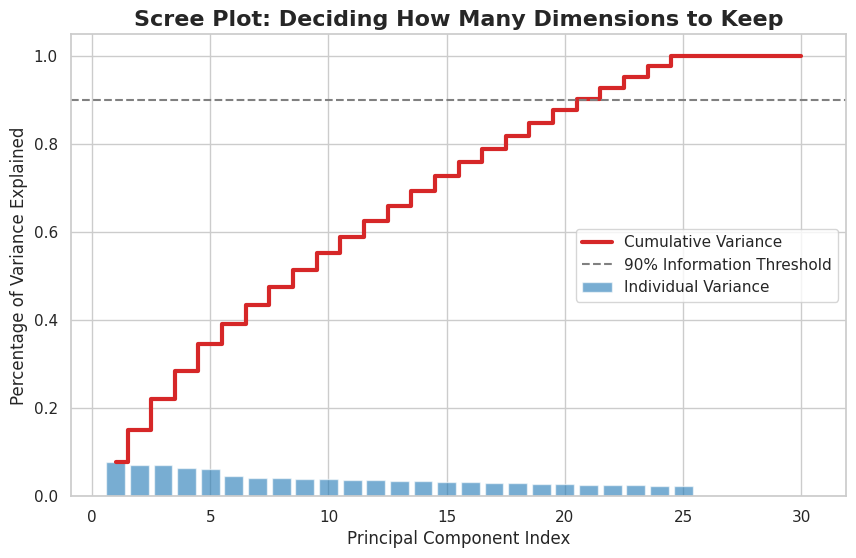

In [3]:
# 1. Simulate a High-Dimensional Dataset (30 Features)
X_high_dim = np.random.randn(500, 30)

# Inject synthetic correlation so PCA has something to compress
X_high_dim[:, 5:15] = X_high_dim[:, 0:10] * 1.5 + np.random.randn(500, 10) * 0.1

# 2. Train PCA
scaler_hd = StandardScaler()
X_hd_scaled = scaler_hd.fit_transform(X_high_dim)

pca_hd = PCA() # Keep all 30 components initially
pca_hd.fit(X_hd_scaled)

# 3. Calculate Cumulative Explained Variance
explained_variance_ratio = pca_hd.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# 4. Matplotlib Visualization (The Scree Plot)
plt.figure(figsize=(10, 6))

plt.bar(range(1, 31), explained_variance_ratio, alpha=0.6, color='#1f77b4', label='Individual Variance')
plt.step(range(1, 31), cumulative_variance, where='mid', color='#d62728', linewidth=3, label='Cumulative Variance')

# Draw a threshold line at 90%
plt.axhline(0.90, color='gray', linestyle='--', label='90% Information Threshold')

plt.title("Scree Plot: Deciding How Many Dimensions to Keep", fontsize=16, fontweight='bold')
plt.xlabel("Principal Component Index")
plt.ylabel("Percentage of Variance Explained")
plt.ylim(0, 1.05)
plt.legend(loc='center right')
plt.show()

*(Insight: Look at the red cumulative line. It crosses the 90% threshold at roughly Component 18. This means we can drop 12 entire columns from our database, massively speeding up our machine learning models, while mathematically guaranteeing we still retain 90% of the original information/variance!)*

# 4. The Limitation of PCA: Non-Linear Manifolds

PCA is a **linear** algorithm. It assumes data relationships are flat straight lines. 
If your data is highly non-linear—like a piece of paper rolled up into a "Swiss Roll" cylinder—PCA will try to squash it flat using a straight line, completely destroying the geometric relationships between points.

For non-linear enterprise data (like image embeddings or complex gene sequencing), data scientists pivot to advanced **Manifold Learning** algorithms like **t-SNE** (t-Distributed Stochastic Neighbor Embedding) or **UMAP** (Uniform Manifold Approximation and Projection). These algorithms do not use linear algebra; they use advanced probability and topology to unroll complex 3D shapes into 2D maps.

## Real-World Use Case or Analogy:
Think of Principal Component Analysis like **Taking a Photograph of a 3D Object**:

* **The Original Data ($X$)**: You have a 3D physical object, like a teapot. It exists in 3 dimensions ($x, y, z$).
* **The Problem**: You need to put a picture of the teapot in a 2D physical magazine. You must drop a dimension.
* **The Optimization (PCA)**: If you take the photo from directly above, looking straight down the spout, it just looks like a confusing circle. You lost all the variance (the shape of the handle, the curve of the base). 
* **The Principal Component**: PCA mathematically calculates the exact optimal camera angle to capture the maximum spread of the teapot. It finds the angle where the handle is on the far left and the spout is on the far right. It takes the 2D photograph from *that exact angle*, ensuring that even though you lost depth, you retained the maximum possible recognizable information.

---